**Import Basic Libraries**

In [2]:
import pandas as pd
import numpy as np
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')
df.head()

Saving Unemployment_Rate_upto_11_2020.csv to Unemployment_Rate_upto_11_2020.csv


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


**Unemployment Rate Data Analysis**

In [3]:
#Check dataset information
print(df.info())

#Check missing values
print(df.isnull().sum())

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

#Display cleaned column names
print(df.columns)

#Analyze unemployment rate
print(df['Estimated Unemployment Rate (%)'].describe())

#Calculate average unemployment rate
average_rate = df['Estimated Unemployment Rate (%)'].mean()

print("Average Unemployment Rate:", average_rate)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB
None
Region                                      0
 

**Data Cleaning, Exploration and Visualization**

           Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-01-2020         M                             5.48   
1  Andhra Pradesh   29-02-2020         M                             5.83   
2  Andhra Pradesh   31-03-2020         M                             5.79   
3  Andhra Pradesh   30-04-2020         M                            20.51   
4  Andhra Pradesh   31-05-2020         M                            17.43   

   Estimated Employed  Estimated Labour Participation Rate (%) Region.1  \
0            16635535                                    41.02    South   
1            16545652                                    40.90    South   
2            15881197                                    39.18    South   
3            11336911                                    33.10    South   
4            12988845                                    36.46    South   

   longitude  latitude  
0    15.9129     79.74  
1    15.9129     79.74  
2    15.912

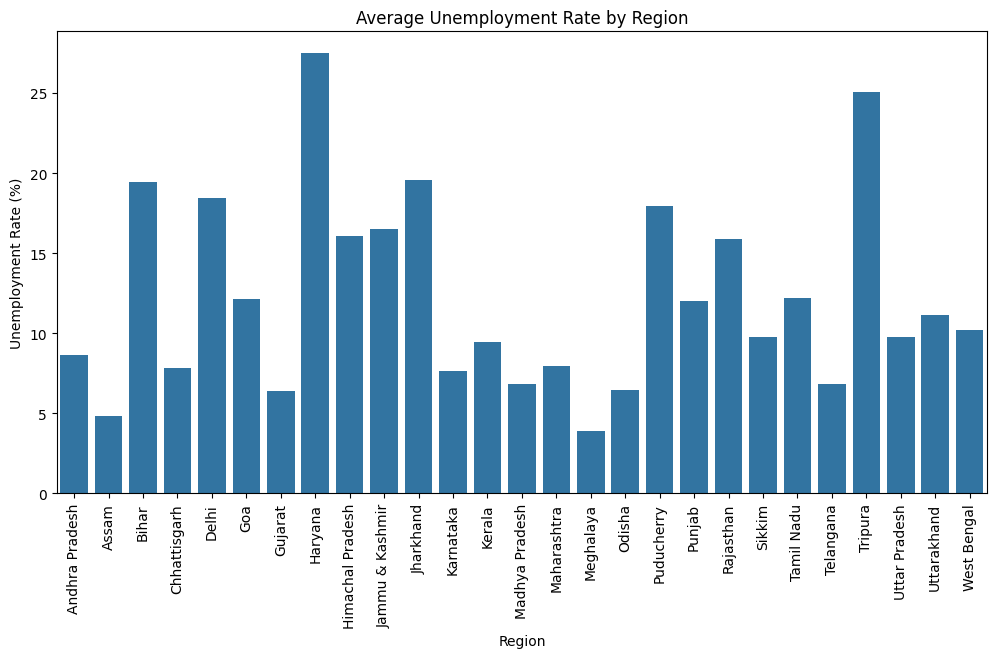

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

#Data Cleaning
df.columns = df.columns.str.strip()   #Remove extra spaces
df.dropna(inplace=True)               #Remove missing values

#Data Exploration
print(df.head())
print(df.info())
print(df.describe())

#Average unemployment rate by region
region_unemployment = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

print(region_unemployment)

#Visualization
plt.figure(figsize=(12,6))

sns.barplot(
    x=region_unemployment.index,
    y=region_unemployment.values
)

plt.xticks(rotation=90)

plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Unemployment Rate (%)')

plt.show()

**Unemployment Rate Trend Overtime**

/tmp/ipykernel_19813/426042616.py:11: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


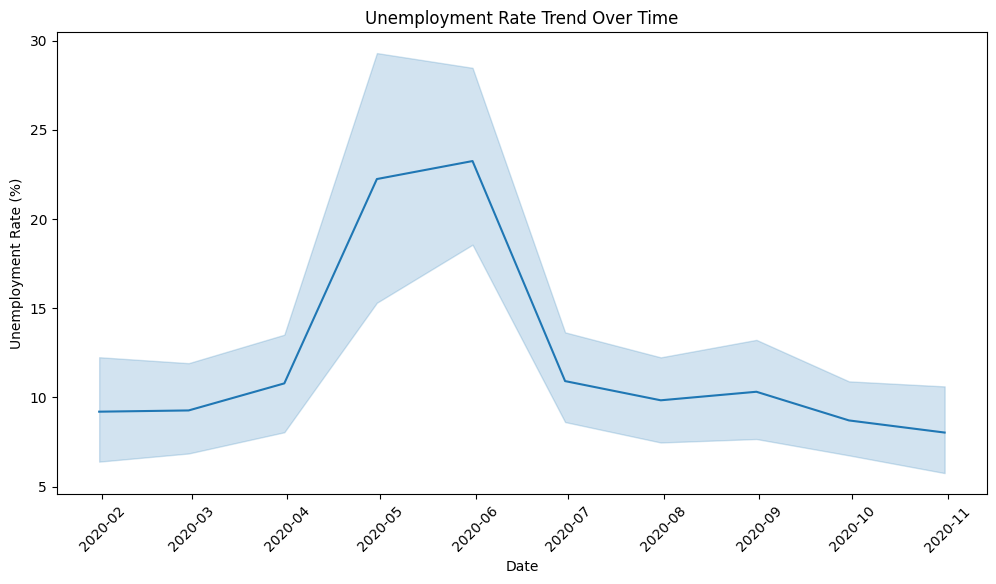

In [5]:
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Data cleaning
df.columns = df.columns.str.strip()
df.dropna(inplace=True)

#Convert Date column into datetime format
df['Date'] = pd.to_datetime(df['Date'])

#Line plot
plt.figure(figsize=(12,6))

sns.lineplot(
    x='Date',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title('Unemployment Rate Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')

plt.xticks(rotation=45)

plt.show()

**Distribution of Unemployment Rate**

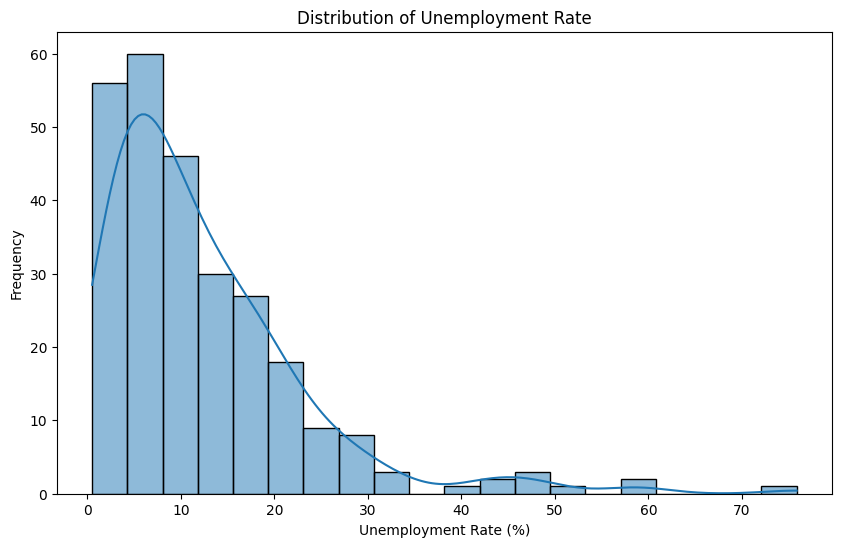

In [6]:
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Histogram
plt.figure(figsize=(10,6))

sns.histplot(
    df['Estimated Unemployment Rate (%)'],
    bins=20,
    kde=True
)

plt.title('Distribution of Unemployment Rate')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Frequency')

plt.show()

**Impact of Covid-19 on unemployment rates**

Average Unemployment Rate Before Covid-19: 9.231346153846154
Average Unemployment Rate During Covid-19: 12.963860465116278


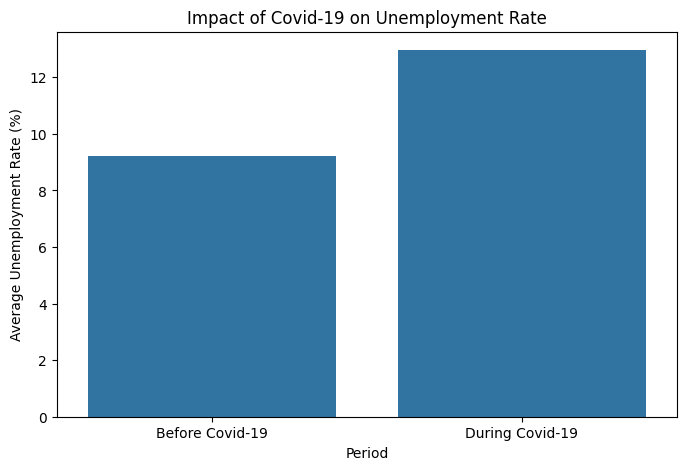

In [7]:
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Convert Date column into datetime format
df['Date'] = pd.to_datetime(df['Date'])

#Separate data before and during Covid-19
before_covid = df[df['Date'] < '2020-03-01']
during_covid = df[df['Date'] >= '2020-03-01']

#Calculate average unemployment rates
before_rate = before_covid['Estimated Unemployment Rate (%)'].mean()
during_rate = during_covid['Estimated Unemployment Rate (%)'].mean()

print("Average Unemployment Rate Before Covid-19:", before_rate)
print("Average Unemployment Rate During Covid-19:", during_rate)

#Visualization
covid_data = pd.DataFrame({
    'Period': ['Before Covid-19', 'During Covid-19'],
    'Unemployment Rate': [before_rate, during_rate]
})

plt.figure(figsize=(8,5))

sns.barplot(
    x='Period',
    y='Unemployment Rate',
    data=covid_data
)

plt.title('Impact of Covid-19 on Unemployment Rate')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')

plt.show()

**Seasonal Trends**: The analysis of unemployment data shows that unemployment rates do not remain constant throughout the year and often follow noticeable patterns. Certain months show higher unemployment rates, which may be linked to seasonal job availability, economic conditions, or external events such as the Covid-19 pandemic. In some periods, unemployment increases due to reduced economic activity, while in other months it decreases when job opportunities improve. Overall, the data indicates that unemployment is influenced by both seasonal changes and unexpected economic disruptions, making it important to monitor trends over time for better understanding and planning.

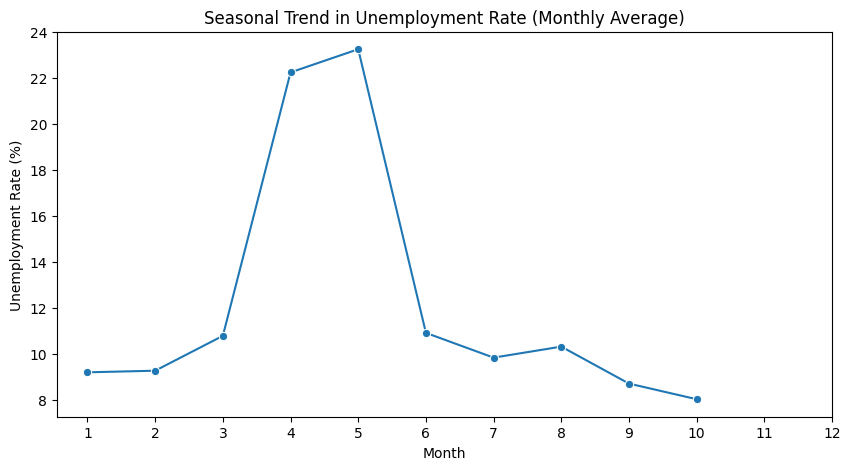

In [8]:
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

#Extract month and year for seasonal analysis
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

#Monthly average unemployment rate
monthly_trend = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

#Plot seasonal pattern
plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_trend.index,
    y=monthly_trend.values,
    marker='o'
)

plt.title('Seasonal Trend in Unemployment Rate (Monthly Average)')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate (%)')

plt.xticks(range(1,13))

plt.show()

**Insights for Economic & Social Policies**

**1. Targeted Employment Programs**: The data shows unemployment is higher in certain regions and time periods. Governments should design region-specific job programs instead of applying one national strategy, as unemployment is not evenly distributed.

**2. Crisis-Responsive Policies (e.g., Covid-19 impact)**: A sharp rise in unemployment during crisis periods (like Covid-19) highlights the need for emergency employment schemes, such as:

a) temporary wage subsidies

b) public work programs

c) financial support for small businesses

**3. Seasonal Job Support**: Since unemployment shows seasonal patterns, policies should support seasonal workers, especially in sectors like agriculture, tourism, and informal labor, through:

a) off-season income support

b) skill diversification programs

**4. Skill Development & Training**: High unemployment rates in some regions suggest a skills mismatch. Governments should invest in:

a) vocational training

b) digital skills programs

c) industry-specific certifications

This improves employability and reduces long-term unemployment.

**5. Focus on Rural vs Urban Gaps**

If rural unemployment is higher or fluctuates more, policies should:

a) promote rural industrialization

b) improve local job creation

c) support small enterprises in rural areas

**6. Data-Driven Policy Making**: Regular monitoring of unemployment trends helps governments:

a) predict economic stress early

b) adjust labor policies in real time

c) allocate resources more efficiently

Overall, unemployment data shows that joblessness is influenced by economic shocks, regional differences, and seasonal changes. Effective policy must therefore be adaptive, region-specific, and focused on skill development and crisis readiness.